运行本笔记本，请点击 "*Runtime*"，然后在**免费** Tesla T4 Google Colab 实例上点击 "*Run all*"！
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> 如有问题请加入 Discord + ⭐ <i>在 <a href="https://github.com/unslothai/unsloth">Github</a> 上给我们点个 Star</i> ⭐
</div>

在本地设备上安装 Unsloth，请参阅[我们的指南](https://unsloth.ai/docs/get-started/install)。本笔记本采用 [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme) 许可证。

你将学习如何进行[数据准备](#Data)、如何[训练](#Train)、如何[运行模型](#Inference)以及如何保存模型

### 最新动态

隆重推出 **Unsloth Studio** —— 一款全新的开源、无代码 Web UI，用于训练和运行大语言模型。[博客](https://unsloth.ai/docs/new/studio)

<table><tr>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia%26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&width=376&dpr=3&quality=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>训练模型</b> — 无需编写代码</sub></td>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26token%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&width=376&dpr=3&quality=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio Chat UI"></a><br><sub><b>在 Mac、Windows 和 Linux 上运行 GGUF 模型</b></sub></td>
</tr></table>

训练 MoE 模型（DeepSeek、GLM、Qwen 和 gpt-oss）速度提升 12 倍，VRAM 减少 35%。[博客](https://unsloth.ai/docs/new/faster-moe)

超长上下文强化学习已支持，上下文窗口扩大 7 倍！[博客](https://unsloth.ai/docs/new/grpo-long-context)

强化学习新功能：[FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

访问我们的文档以查看所有[模型上传](https://unsloth.ai/docs/get-started/unsloth-model-catalog)和[笔记本](https://unsloth.ai/docs/get-started/unsloth-notebooks)。

### 安装

In [ ]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d 仅支持 torch==2.8.0。如果你的 torch 版本更新，请等待 10 分钟！
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0

### Unsloth

In [ ]:
from unsloth import FastVisionModel # LLM 请使用 FastLanguageModel
import torch

# 我们支持的 4 位预量化模型，下载速度提升 4 倍且无显存溢出（OOM）。
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # 支持 Llama 3.2 视觉模型
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # 可运行在 80GB 显存卡上！
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral 可运行在 16GB 显存卡上！
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral 基础模型

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # 支持 Qwen2 视觉语言模型
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # 任何 Llava 变体均可使用！
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # 更多模型详见 https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-2B",
    load_in_4bit = False, # 使用 4 位精度以减少内存占用。设为 False 则使用 16 位 LoRA。
    use_gradient_checkpointing = "unsloth", # True 或 "unsloth" 用于长上下文
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.2.1: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/336 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

现在我们为参数高效微调添加 LoRA 适配器——这使我们只需高效地训练全部参数的 1%。

**[新功能]** 我们现在还支持仅微调模型的视觉部分，或仅微调语言部分，也可以两者同时微调！你还可以选择微调注意力层或 MLP 层！

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # 若不微调视觉层，设为 False
    finetune_language_layers   = True, # 若不微调语言层，设为 False
    finetune_attention_modules = True, # 若不微调注意力层，设为 False
    finetune_mlp_modules       = True, # 若不微调 MLP 层，设为 False

    r = 16,           # 值越大精度越高，但可能过拟合
    lora_alpha = 16,  # 推荐 alpha 至少等于 r
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # 我们支持秩稳定 LoRA
    loftq_config = None, # 以及 LoftQ
    # target_modules = "all-linear", # 现在为可选参数！如有需要可指定列表
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


<a name="Data"></a>
### 数据准备
我们将使用一个手写数学公式的采样数据集。目标是将这些图像转换为计算机可读的形式——即 LaTeX 格式，以便我们可以渲染它。这对于复杂公式非常有用。

你可以在[这里](https://huggingface.co/datasets/unsloth/LaTeX_OCR)访问数据集。完整数据集在[这里](https://huggingface.co/datasets/linxy/LaTeX_OCR)。

In [ ]:
from datasets import load_dataset
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

让我们对数据集进行整体浏览。我们将查看第 3 张图像及其对应的标注内容。

In [ ]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

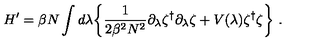

In [ ]:
dataset[2]["image"]

In [ ]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

我们也可以直接在浏览器中渲染 LaTeX！

In [ ]:
from IPython.display import display, Math, Latex

latex = dataset[2]["text"]
display(Math(latex))

<IPython.core.display.Math object>

为了格式化数据集，所有视觉微调任务都应按如下格式进行处理：

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

In [ ]:
instruction = "Write the LaTeX representation for this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

让我们将数据集转换为适合微调的"正确"格式：

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

让我们看看第一个示例中对话是如何组织的：

In [ ]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

在开始微调之前，让我们先看看模型对第一个示例的输出！

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

 $$H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} .$$<|im_end|>
<|endoftext|>


<a name="Train"></a>
### 训练模型
现在让我们训练模型。为了加快速度，我们只运行 30 步，但你可以设置 `num_train_epochs=1` 进行完整训练，并将 `max_steps=None` 关闭。我们还支持用于强化学习的 `DPOTrainer` 和 `GRPOTrainer`！

我们使用全新的 `UnslothVisionDataCollator`，它将帮助我们完成视觉微调设置。

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # 启用训练模式！

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # 必须使用！
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # 完整训练时设置此参数代替 max_steps
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # 用于 Weights and Biases

        # 以下参数是视觉微调的必填项：
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
# @title 显示当前显存统计
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
4.514 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 23,110,656 of 2,236,352,320 (1.03% trained)


Step,Training Loss
1,0.631942
2,0.781121
3,0.835430
4,0.692773
5,0.668855
6,0.895739
7,0.856702
8,0.714944
9,0.512467
10,0.560102


In [ ]:
# @title 显示最终显存与时间统计
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

559.2975 seconds used for training.
9.32 minutes used for training.
Peak reserved memory = 5.146 GB.
Peak reserved memory for training = 0.632 GB.
Peak reserved memory % of max memory = 35.336 %.
Peak reserved memory for training % of max memory = 4.34 %.


<a name="Inference"></a>
### 推理
让我们运行模型！你可以修改指令和输入——将输出留空即可！

我们使用 `min_p = 0.1` 和 `temperature = 1.5`。阅读这篇[推文](https://x.com/menhguin/status/1826132708508213629)以了解更多原因。

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} .<|im_end|>


<a name="Save"></a>
### 保存与加载微调模型
要将最终模型保存为 LoRA 适配器，可使用 Hugging Face 的 `push_to_hub` 在线保存，或使用 `save_pretrained` 本地保存。

**[注意]** 这**只**保存 LoRA 适配器，而非完整模型。若要保存为 16 位或 GGUF 格式，请向下滚动！

In [ ]:
model.save_pretrained("qwen_lora")  # 本地保存
tokenizer.save_pretrained("qwen_lora")
# model.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # 在线保存
# tokenizer.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # 在线保存

['qwen_lora/processor_config.json']

现在，如果你想加载刚刚保存的 LoRA 适配器进行推理，请将 `False` 改为 `True`：

In [ ]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "qwen_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[0]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

\frac { N } { M } \in { \bf Z } , \frac { M } { P } \in { \bf Z } , \frac { P } { Q } \in { \bf Z }<|im_end|>


### 保存为 float16 格式（用于 VLLM）

我们也支持直接保存为 `float16` 格式。选择 `merged_16bit` 即可保存为 float16。使用 `push_to_hub_merged` 上传到你的 Hugging Face 账户！前往 https://huggingface.co/settings/tokens 获取你的个人令牌。查看[我们的文档](https://unsloth.ai/docs/basics/inference-and-deployment)以了解更多部署选项。

In [ ]:
# 只选择其中一种方式保存！（无需两者都保存）

# 本地保存为 16 位格式
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# 导出并保存到你的 Hugging Face 账户
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp 转换
现在我们原生支持保存为 `GGUF` / `llama.cpp` 格式！我们会克隆 `llama.cpp` 并默认保存为 `q8_0`。也支持所有其他量化方法，如 `q4_k_m`。使用 `save_pretrained_gguf` 进行本地保存，使用 `push_to_hub_gguf` 上传到 HF。

部分支持的量化方法（完整列表见[文档页面](https://unsloth.ai/docs/basics/inference-and-deployment/saving-to-gguf)）：
* `q8_0` - 转换速度快。资源消耗较高，但通常可以接受。
* `q4_k_m` - 推荐。对一半的 attention.wv 和 feed_forward.w2 张量使用 Q6_K，其余使用 Q4_K。
* `q5_k_m` - 推荐。对一半的 attention.wv 和 feed_forward.w2 张量使用 Q6_K，其余使用 Q5_K。

[**新功能**] 若要微调并自动导出到 Ollama，请尝试我们的 [Ollama 笔记本](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [ ]:
# 保存为 8 位 Q8_0 格式
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
# 记得前往 https://huggingface.co/settings/tokens 获取令牌！
# 并将 HF_USERNAME 替换为你的用户名！
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# 保存为 16 位 GGUF 格式
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "f16", token = "YOUR_HF_TOKEN")

# 保存为 q4_k_m GGUF 格式
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# 保存为多种 GGUF 格式——同时导出多种格式时速度更快！
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/qwen_finetune", # 将 HF_USERNAME 替换为你的用户名！
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN",
    )

大功告成！如有关于 Unsloth 的问题，欢迎加入我们的 [Discord](https://discord.gg/unsloth) 频道！如果发现 bug、想及时获取最新 LLM 动态、需要帮助或参与项目，欢迎加入我们的 Discord！

其他资源：
1. 想在本地使用 Unsloth？阅读我们的[安装指南](https://unsloth.ai/docs/get-started/install)，了解在 Windows、Docker、AMD、Intel GPU 上安装的详细说明。
2. 通过我们的[强化学习指南与笔记本](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide)学习强化学习。
3. 阅读我们关于[文字转语音（TTS）](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning)和[视觉](https://unsloth.ai/docs/basics/vision-fine-tuning)模型支持的指南与笔记本。
4. 探索我们的 [LLM 教程目录](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms)，查找每个模型的专属指南。
5. 推理遇到问题？阅读我们的[推理与部署页面](https://unsloth.ai/docs/basics/inference-and-deployment)，了解使用 vLLM、llama.cpp、Ollama 等工具的详细信息。

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  如有问题请加入 Discord + ⭐️ <i>在 <a href="https://github.com/unslothai/unsloth">Github</a> 上给我们点个 Star</i> ⭐️

  <b>本笔记本及所有 Unsloth 笔记本均采用 <a href="https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme">LGPL-3.0</a> 许可证</b>
</div>